# 澳洲学签数据审计与生存模型基线

## tl;dr

本 notebook 固化官方 BP0015 月度流量核验、数据层边界、VisaDashboard 个案质量审计、固定时间切分生存模型比较和最终留出验证。部署模型为 Weibull AFT，但最终留出 C-index 仅约 0.53，因此置信等级为 limited。

重要边界：官方 `lodged - granted` 是两个流量之差，不是 pending inventory；众包个案缺少国籍字段，因此中国 PGR 官方流量只能作为滞后上下文代理。

In [1]:
from pathlib import Path
import csv, json

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
FLOW = ROOT / 'data' / '14_official_monthly_flows_2015-2026.csv'
CASES = ROOT / 'data' / '11_visadashboard_cases.csv'
AUDIT = ROOT / 'reports' / 'data_quality_audit.json'
MODEL = ROOT / 'models' / 'subclass500_survival_v3.json'

## 1. 官方月度流量完整性

精确口径：Primary、Outside Australia、China PRC excluding SARs、Postgraduate Research Sector；快照截止 2026-08-31。

In [2]:
with FLOW.open(encoding='utf-8-sig', newline='') as handle:
    flows = list(csv.DictReader(handle))
assert len(flows) == 280
assert {row['activity_type'] for row in flows} == {'lodged', 'granted'}
assert min(row['activity_month'] for row in flows) == '2015-01'
assert max(row['activity_month'] for row in flows) == '2026-08'

for year in ('2025', '2026'):
    totals = {kind: sum(int(r['count']) for r in flows if r['activity_type'] == kind and r['activity_month'].startswith(year)) for kind in ('lodged', 'granted')}
    print(year, totals)

2025 {'lodged': 2168, 'granted': 1857}
2026 {'lodged': 1405, 'granted': 1022}


## 2. 众包个案审计

建模前应用质量阈值 40，并按 `duplicate_key` 保留质量最高的一条。训练截止点之后才观察到的结案，在训练集中重建为截止点右删失。

In [3]:
audit = json.loads(AUDIT.read_text(encoding='utf-8'))
summary = {
    'raw_rows': audit['rows'],
    'model_rows': audit['uniqueness']['rows_after_quality_and_dedup'],
    'duplicate_timeline_groups': audit['uniqueness']['duplicate_timeline_groups'],
    'test_rows': audit['temporal_split']['test_rows'],
    'test_events': audit['temporal_split']['test_observed_events'],
    'test_censored': audit['temporal_split']['test_right_censored'],
}
summary

{'raw_rows': 1511,
 'model_rows': 1460,
 'duplicate_timeline_groups': 41,
 'test_rows': 317,
 'test_events': 270,
 'test_censored': 47}

## 3. 固定时间切分回测

训练：递签日不晚于 2024-12-31；测试：2025-01-01 至 2025-08-31。C-index 越高越好，Brier score 越低越好。事件专用 MAE/覆盖率会受仅观察到结案样本的选择影响。

In [4]:
artifact = json.loads(MODEL.read_text(encoding='utf-8'))
rows = []
for item in artifact['evaluations']:
    rows.append({
        'model': item['model'],
        'c_index': item['harrell_c_index'],
        'mae_event_days': item['event_only_median_absolute_error_days'],
        'coverage_event': item['event_only_p10_p90_coverage'],
        'brier_180': item['horizon_calibration']['180']['brier_score'],
    })
print('selected on development window:', artifact['selected_baseline'])
for row in sorted(rows, key=lambda r: -(r['c_index'] or 0)):
    print(row)
print('deployment holdout:', artifact['deployment_holdout_evaluation'])
print('rejected calibration candidate:', artifact['candidate_calibration_holdout_evaluation'])

selected on development window: weibull_aft
{'model': 'weibull_aft', 'c_index': 0.6067, 'mae_event_days': 90.3, 'coverage_event': 0.7074, 'brier_180': 0.2363}
{'model': 'cox_ph', 'c_index': 0.6026, 'mae_event_days': 72.5, 'coverage_event': 0.6926, 'brier_180': 0.2688}
{'model': 'random_survival_forest', 'c_index': 0.5917, 'mae_event_days': 87.5, 'coverage_event': 0.8099, 'brier_180': 0.2232}
{'model': 'kaplan_meier_global', 'c_index': 0.5, 'mae_event_days': 79.0, 'coverage_event': 0.7926, 'brier_180': 0.2569}
{'model': 'kaplan_meier_stratified', 'c_index': 0.482, 'mae_event_days': 76.5, 'coverage_event': 0.7926, 'brier_180': 0.2536}
deployment holdout: {'model': 'weibull_aft', 'test_rows': 164, 'test_events': 135, 'test_censored': 29, 'harrell_c_index': 0.531, 'comparable_pairs': 12863, 'event_only_median_absolute_error_days': 97.3, 'event_only_p10_p90_coverage': 0.7778, 'event_only_interval_rows': 135, 'horizon_calibration': {'90': {'brier_score': 0.1517, 'mean_predicted_decision_prob

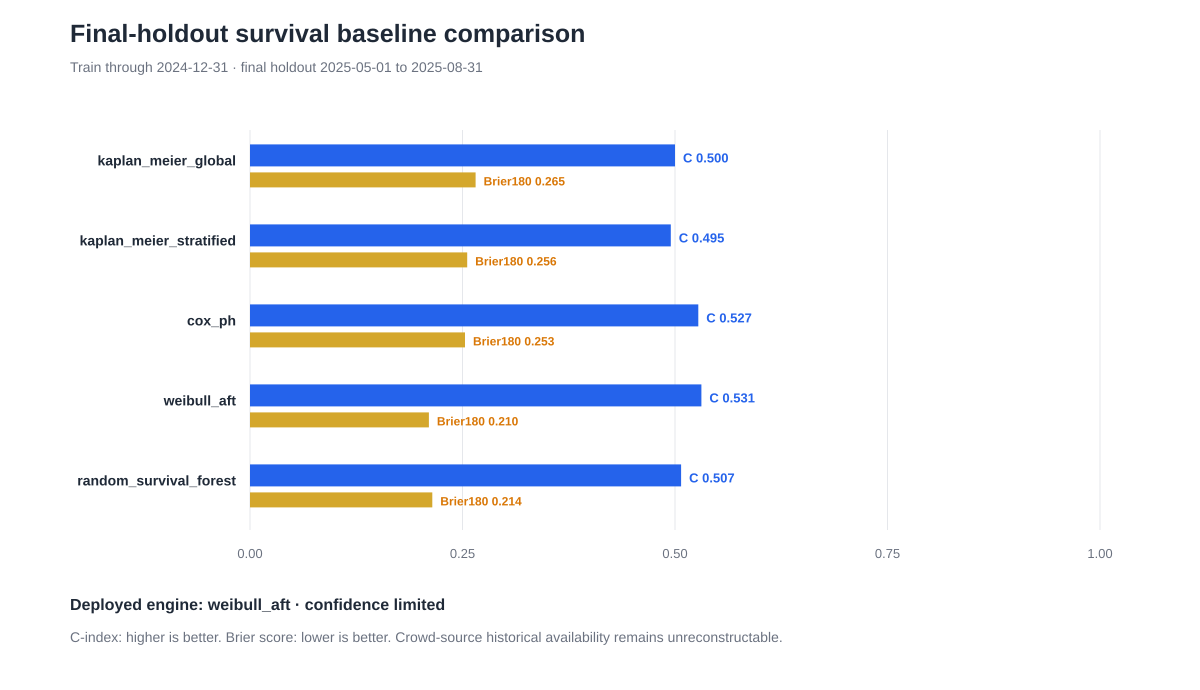

In [5]:
# 在具备 Jupyter/IPython 的环境中显示由同一 artifact 生成的比较图。
from IPython.display import SVG, display
display(SVG(filename=str(ROOT / 'reports' / 'figures' / 'backtest_calibration.svg')))

## 4. 可选重建

下列单元格默认不重跑。设 `REBUILD=True` 后，会从标准化个案表重新生成审计与五个纯 Python 生存基线 artifact。官方原始 XLSX 的刷新应先运行 `python 等签算法.py official-refresh`。

In [6]:
REBUILD = False
if REBUILD:
    from visa_wait.audit import write_audit_report
    from visa_wait.baselines import train_survival_baselines
    write_audit_report(CASES, AUDIT, ROOT / 'reports' / 'data_quality_audit.md')
    train_survival_baselines(cases_path=CASES, official_flows_path=FLOW, output=MODEL)

## 结论与限制

开发窗口中 Weibull AFT 的区分度约为 0.61，但 2025-05 至 2025-08 最终留出窗口只有约 0.53，显示明显的时间漂移。等距概率校准候选虽然改善部分 Brier 指标，却使事件样本中位误差明显变差，因此没有部署。所有众包记录在 2026 年同一快照中首次抓取，无法还原每条记录何时首次公开；模型预测的是作出决定的时间，不预测是否获签。